In [1]:
from qiskit.providers.fake_provider import FakeManilaV2
from numpy import pi as π, random
from qiskit import QuantumCircuit, transpile
from qiskit.circuit import Parameter
from qiskit_aer import AerSimulator

backend = FakeManilaV2()
simulator = AerSimulator()

In [2]:
from matplotlib import pyplot as plt

def makePlots(hits, ticks, labels):
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    ax1.hist(hits, bins=100)
    ax1.set_xticks(ticks)
    ax1.set_xticklabels(labels)
    ax1.set_ylabel('Counts')
    ax1.grid(axis='y', linestyle='dashed')

    ax2.scatter(hits, random.uniform(-1, 1, len(hits)), s=1)
    ax2.tick_params(axis='both', left=False, labelleft=False)
    ax2.set_xticks(ticks)
    ax2.set_xticklabels(labels)
    ax2.set_xlabel('phi (Screen)')
    return plt

In [3]:
screen_size = 6*π
range_arr = range(-3, 3)
runs = 1024

In [4]:
phi = Parameter('phi')

qc = QuantumCircuit(1,1)
qc.h(0)
qc.p(phi,0)
qc.h(0)
qc.measure(0,0)

# We do this to make it more efficient for the given backend
qc = transpile(qc, backend=simulator)
qc.draw()

┌───┐┌────────┐┌───┐┌─┐
  q: ┤ H ├┤ P(phi) ├┤ H ├┤M├
     └───┘└────────┘└───┘└╥┘
c: 1/═════════════════════╩═
                          0

In [5]:
phases = random.uniform( -screen_size/2, + screen_size/2, runs)

circuits = []
for phase in phases:
    qc_sim = qc.assign_parameters({ phi: phase })
    circuits.append(qc_sim)

circuits[6].draw()

┌───┐┌────────────┐┌───┐┌─┐
  q: ┤ H ├┤ P(-3.2286) ├┤ H ├┤M├
     └───┘└────────────┘└───┘└╥┘
c: 1/═════════════════════════╩═
                              0

In [6]:
results = simulator.run(circuits, shots=1, memory=True).result()
hits = [
    phases[i]
        for i, circ in enumerate(circuits)
        # 0 implies HIT on screen
        if results.get_memory(circ)[0] == '0'
]

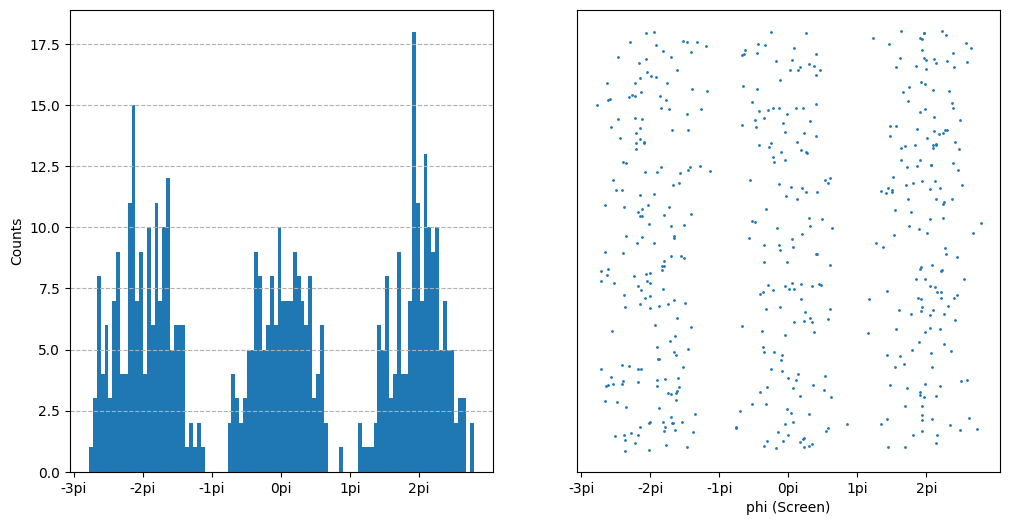

In [7]:
ticks = [i*π for i in range_arr]
labels = [str(i)+"pi" for i in range_arr]

# This shows us what the screen distribution is
makePlots(hits, ticks, labels).show()

## Adding a 'detector' to the path

In [8]:
# define quantum circuit equivalent to double-slit experiment WITH measurement after slits
qc = QuantumCircuit(1,1)
qc.h(0)
qc.measure(0,0)
qc.p(phi,0)
qc.h(0)
qc.measure(0,0)

qc = transpile(qc, backend=simulator)
qc.draw()

┌───┐┌─┐┌────────┐┌───┐┌─┐
  q: ┤ H ├┤M├┤ P(phi) ├┤ H ├┤M├
     └───┘└╥┘└────────┘└───┘└╥┘
c: 1/══════╩═════════════════╩═
           0                 0

In [9]:
phases = random.uniform( -screen_size/2, + screen_size/2, runs)

circuits = []
for phase in phases:
    qc_sim = qc.assign_parameters({ phi: phase })
    circuits.append(qc_sim)

circuits[6].draw()

┌───┐┌─┐┌───────────┐┌───┐┌─┐
  q: ┤ H ├┤M├┤ P(1.0204) ├┤ H ├┤M├
     └───┘└╥┘└───────────┘└───┘└╥┘
c: 1/══════╩════════════════════╩═
           0                    0

In [10]:
# Post-process results: select values of φ where we measured a 0 (i.e., particle hit the screen)
sim_results = simulator.run(circuits, shots=1, memory=True).result()
hits = [
    phases[i]
        for i, circ in enumerate(circuits)
        # 0 implies HIT on screen
        if sim_results.get_memory(circ)[0] == '0'
]

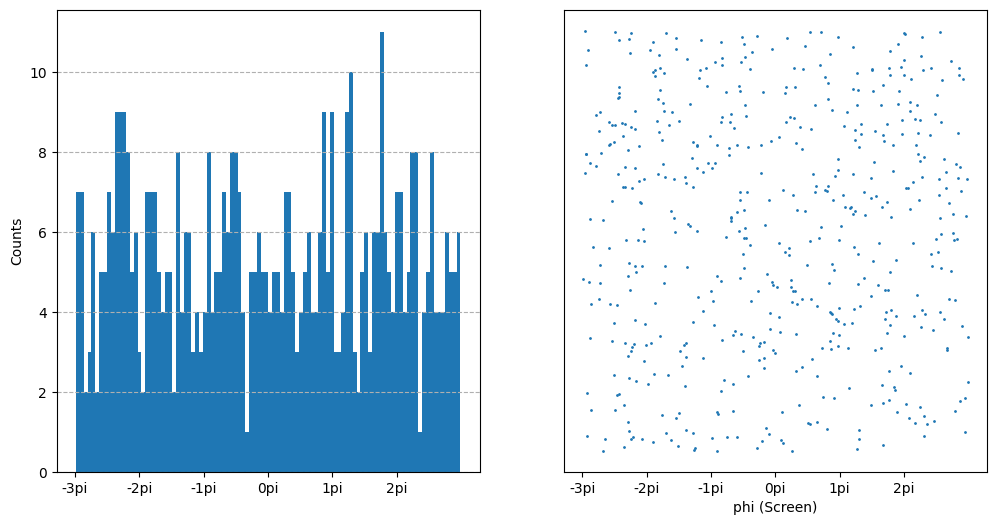

In [11]:
makePlots(hits, ticks, labels).show()